In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

Cargo los datos inmobiliarios

In [2]:
df_inm = pd.read_csv("C:/Users/Ariela/Desktop/EDA - Inmobiliario/Inmobiliario/src/data/EDA_Inmob_Nunoa.csv")

In [3]:
df_inm.head(5)

,titulo,precio,dormitorios,baños,m2,codigo,estacionamientos,fecha
0,Av. Vicuña Mackenna 1207,$ 300.000,1.0,1.0,46 m²,74178321,0,03/04/2026
1,José Domingo Cañas,$ 495.000,1.0,1.0,39 m²,89803699,0,02/04/2026
2,Avenida Grecia 1355,$ 700.000,3.0,2.0,120 m²,111212760,0,01/04/2026
3,Lincoyán,$ 520.000,1.0,1.0,47 m²,114254710,0,01/04/2026
4,Matta Oriente / Metro Irarrazaval,$ 480.000,2.0,2.0,60 m²,112513364,0,31/03/2026


In [4]:
df_inm.info()

<class 'pandas.DataFrame'>
RangeIndex: 353 entries, 0 to 352
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   titulo            353 non-null    str    
 1   precio            353 non-null    str    
 2   dormitorios       350 non-null    float64
 3   baños             342 non-null    float64
 4   m2                334 non-null    str    
 5   codigo            353 non-null    int64  
 6   estacionamientos  353 non-null    int64  
 7   fecha             353 non-null    str    
dtypes: float64(2), int64(2), str(4)
memory usage: 22.2 KB


In [ ]:
# Corrijo las columnas tipo str
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())  #Voy a corregir la columna de precio, porque piensa que es un str. Elimino el signo $ y los puntos
df_inm['m2'] = pd.to_numeric(df_inm['m2'].str.replace(" m²", "", regex=False).str.replace(",", ".", regex=False))


In [8]:
df_inm['precio_euro'] = df_inm['precio']*0.00094

# Elimino ouliers
p95 = df_inm["precio_euro"].quantile(0.95)
p05 = df_inm["precio_euro"].quantile(0.05)

df_inm = df_inm[(df_inm["precio_euro"] > p05) & (df_inm["precio_euro"] < p95)]

#Limpio los datos que no existen
df_inm = df_inm.dropna()

df_inm.describe()


,precio,dormitorios,baños,m2,codigo,estacionamientos,precio_euro
count,2.910000e+02,291.000000,291.000000,291.000000,2.910000e+02,291.000000,291.000000
mean,6.068215e+05,1.522337,1.367698,50.177557,1.001292e+08,1.006873,570.412241
std,1.629645e+05,0.611964,0.497082,19.220881,2.713876e+07,5.634863,153.186620
min,3.800000e+05,1.000000,1.000000,3.500000,4.025973e+06,0.000000,357.200000
25%,4.979995e+05,1.000000,1.000000,38.000000,1.030500e+08,0.000000,468.119530
50%,5.800000e+05,1.000000,1.000000,45.000000,1.125279e+08,1.000000,545.200000
75%,6.840000e+05,2.000000,2.000000,62.000000,1.138058e+08,1.000000,642.960000
max,1.274935e+06,3.000000,3.000000,120.000000,1.146036e+08,95.000000,1198.438900


(2,)


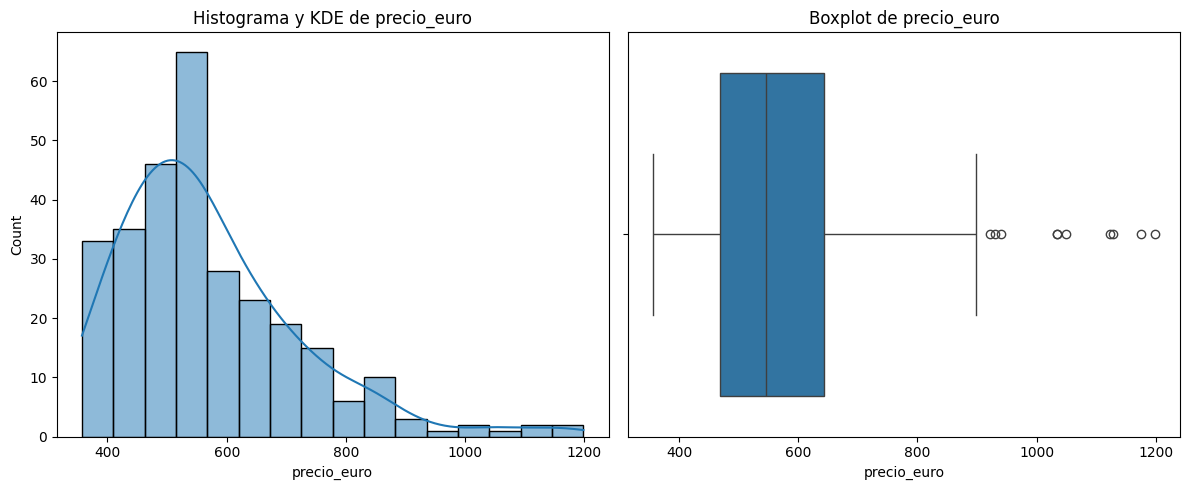

In [9]:
# El 50% es la mediana, el 50% de los datos están por debajo de ese numero

plot_combined_graphs(df_inm,["precio_euro"])

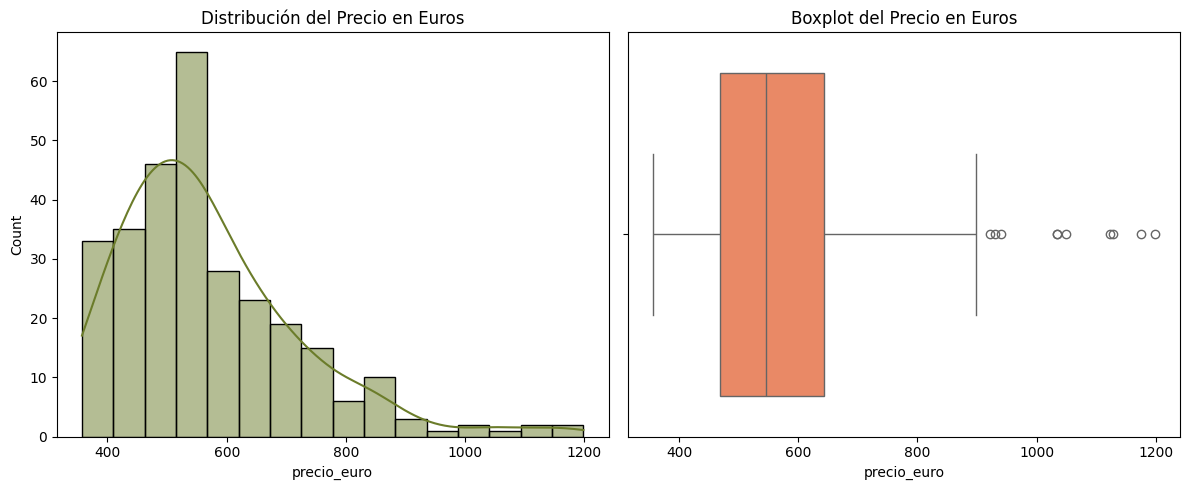

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_inm["precio_euro"], kde=True, ax=axes[0], color="#6B7C2A")
axes[0].set_title("Distribución del Precio en Euros")

sns.boxplot(x=df_inm["precio_euro"], ax=axes[1], color="coral")
axes[1].set_title("Boxplot del Precio en Euros")

plt.tight_layout()
plt.show()

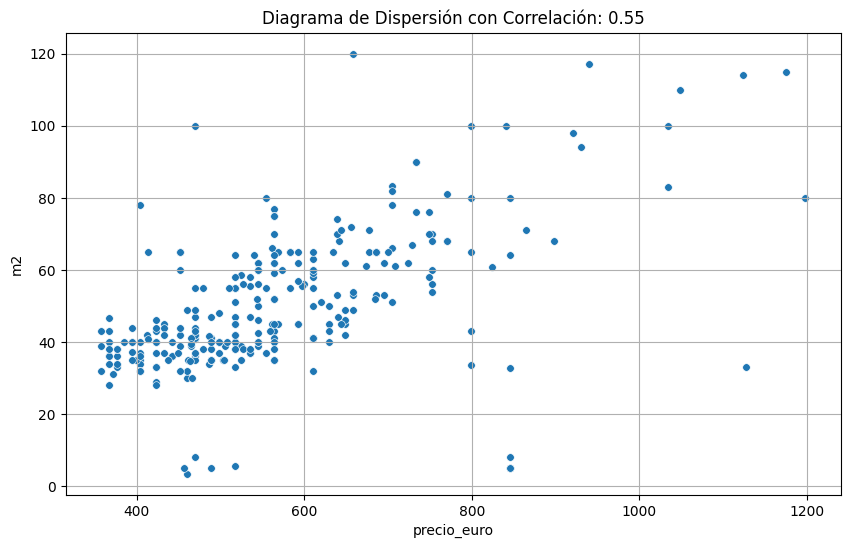

In [11]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precio_euro","m2", mostrar_correlacion= True, tamano_puntos= 30)

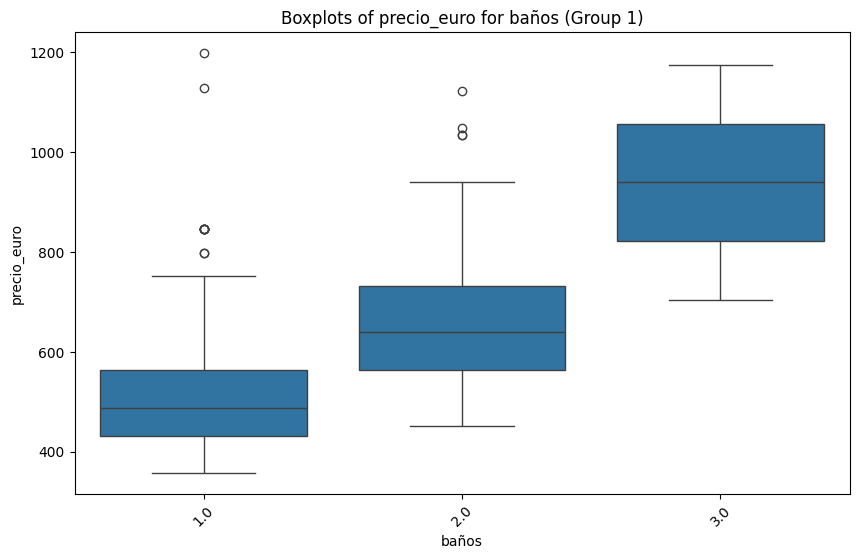

In [12]:
plot_grouped_boxplots(df_inm, "baños","precio_euro")

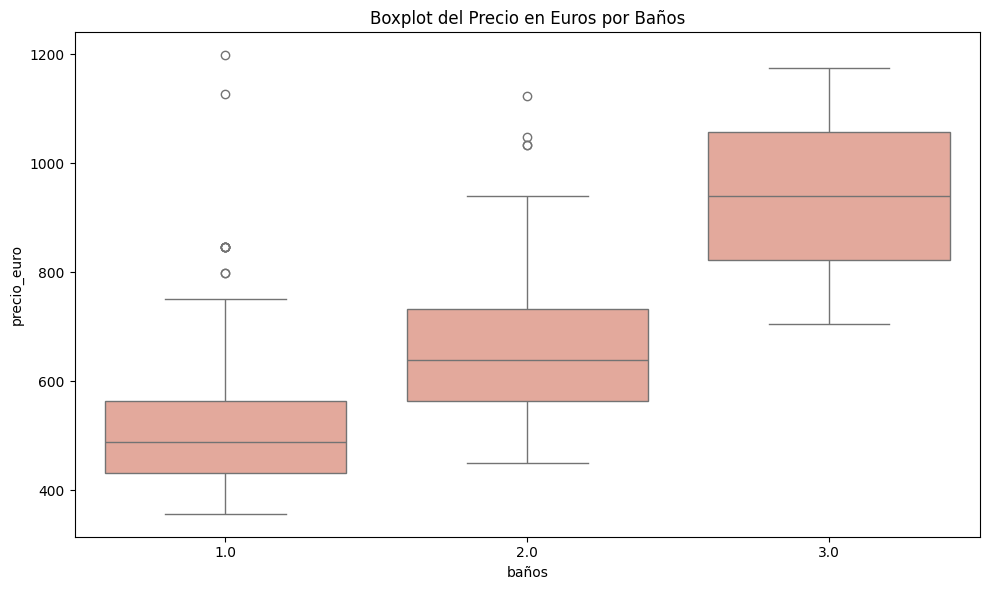

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="baños", y="precio_euro", data=df_inm, ax=ax, color="#EFA19056")
ax.set_title("Boxplot del Precio en Euros por Baños")

plt.tight_layout()
plt.show()

In [ ]:
# Normalizo el precio por m2
df_inm['precioeu_m2'] = df_inm['precio_euro']/df_inm['m2']

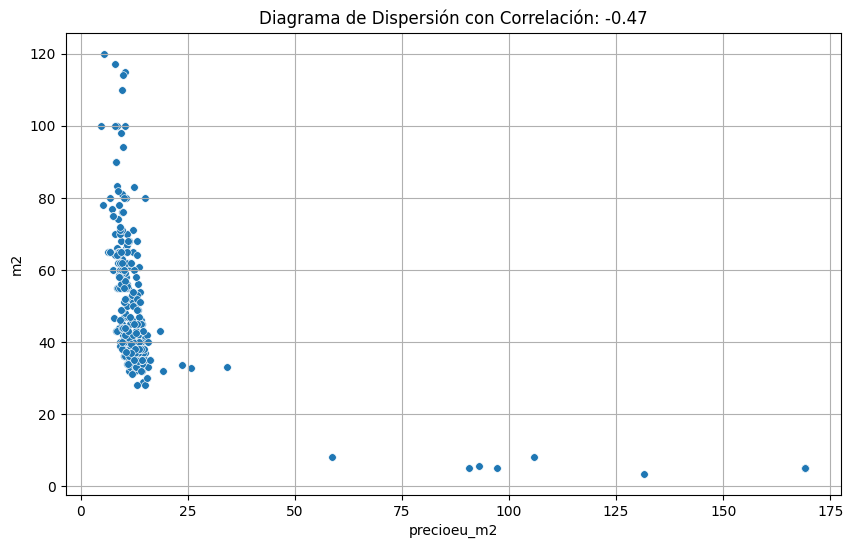

In [ ]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

In [18]:
# Hay algunos valores muy bajos que no tienen sentido, los elimino
filtro = (df_inm.precioeu_m2< 20)#*******
df_inm = df_inm[filtro]

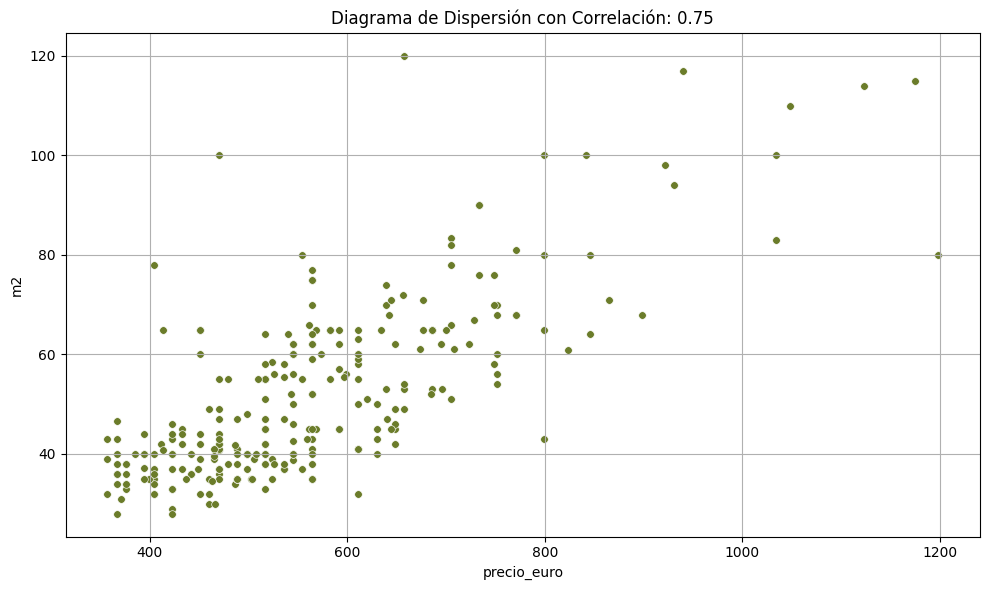

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_inm, x="precio_euro", y="m2", s=30, ax=ax, color="#6B7C2A")

correlacion = df_inm[["precio_euro", "m2"]].corr().iloc[0, 1]
ax.set_title(f"Diagrama de Dispersión con Correlación: {correlacion:.2f}")
ax.set_xlabel("precio_euro")
ax.set_ylabel("m2")
ax.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Análisis por grupo

rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()

,count,mean,std,min,25%,50%,75%,max
grupo_m2,,,,,,,,
<40,90.0,12.680178,1.855654,9.158974,11.308485,12.696351,13.965714,19.093750
40-60,110.0,11.373879,1.970691,7.520000,9.813309,11.149784,12.752336,18.581395
60-80,61.0,9.757163,1.808264,5.182051,8.793548,9.551613,10.742857,14.980486
80-100,12.0,8.839348,1.820056,4.700000,8.146667,8.530981,9.612037,12.457831
100-120,5.0,8.624707,1.942531,5.483333,8.034188,9.533036,9.855587,10.217391


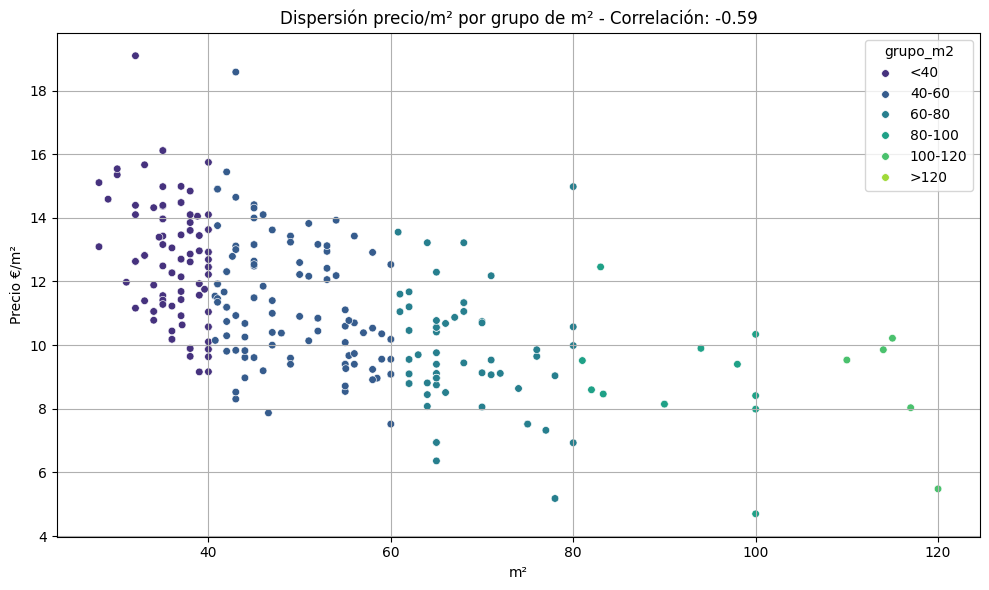

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df_inm, x="m2", y="precioeu_m2", hue="grupo_m2", s=30, ax=ax, palette="viridis")

correlacion = df_inm[["m2", "precioeu_m2"]].corr().iloc[0, 1]
ax.set_title(f"Dispersión precio/m² por grupo de m² - Correlación: {correlacion:.2f}")
ax.set_xlabel("m²")
ax.set_ylabel("Precio €/m²")
ax.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# FILTRO PARA BÚSQUEDA FAMILIA

filtro = (df_inm.dormitorios >= 1)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmb = df_inm[filtro]

# Para comparar con Madrid debo sumar los gastos de la comunidad 
df_inmb["precio_eurogc"] = df_inmb["precio_euro"] + (df_inmb["precio_euro"]*0.2)
df_inmb["precio_eurogcm2"] = (df_inmb["precio_euro"] + (df_inmb["precio_euro"]*0.2))/df_inmb["m2"]

df_inmb.describe()

,precio,dormitorios,baños,m2,codigo,estacionamientos,precio_euro,precioeu_m2,precio_eurogc,precio_eurogcm2
count,6.900000e+01,69.000000,69.000000,69.000000,6.900000e+01,69.000000,69.000000,69.000000,69.000000,69.000000
mean,6.920161e+05,2.072464,1.739130,66.895652,1.054934e+08,0.739130,650.495094,9.745270,780.594113,11.694324
std,1.357686e+05,0.356405,0.442326,5.809081,2.002415e+07,0.933875,127.622486,1.760028,153.146984,2.112034
min,4.300000e+05,1.000000,1.000000,60.000000,1.971014e+07,0.000000,404.200000,5.182051,485.040000,6.218462
25%,6.000000e+05,2.000000,1.000000,62.000000,1.109068e+08,0.000000,564.000000,8.812500,676.800000,10.575000
50%,6.800000e+05,2.000000,2.000000,65.000000,1.131132e+08,1.000000,639.200000,9.551613,767.040000,11.461935
75%,7.700000e+05,2.000000,2.000000,70.000000,1.140890e+08,1.000000,723.800000,10.700342,868.560000,12.840411
max,1.274935e+06,3.000000,2.000000,80.000000,1.145093e+08,7.000000,1198.438900,14.980486,1438.126680,17.976583


In [44]:
rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inmb['grupo_m2'] = pd.cut(df_inmb['m2'], bins=rangos, labels=etiquetas)

df_inmb.groupby('grupo_m2')['precioeu_m2'].describe()[["50%"]]

,50%
grupo_m2,
40-60,9.321667
60-80,9.551613
